# Predicción de abandono de clientes

#### Caso Netflix: https://www.kaggle.com/datasets/abdulwadood11220/netflix-customer-churn-dataset

1 -> ABANDONA

0 -> NO ABANDONA

In [1]:
import pandas as pd
# Cargar el dataset
df_netflix = pd.read_csv('C:/Portfolio/churn_models/input/netflix_customer_churn.csv')
df_netflix.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [2]:
# Revisar el dataset
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

#### 1. Transformar las variables en números para que sea más fácil generar un modelo

In [3]:
# Separar las variables independientes y dependientes
X = df_netflix.drop(columns=['churned', 'customer_id'])
y = df_netflix['churned']

In [4]:
# Verificar las columnas del dataset
X.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')

In [5]:
# Separar en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
print(f"Tamaño de entrenamiento: {len(X_train)*100/len(X)}%")

Tamaño de entrenamiento: 80.0%


In [7]:
# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
standard_scaler = StandardScaler()
categorical_features = X.select_dtypes(include=['object']).columns

for col in categorical_features:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

X_train.head()


,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4227,54,2,1,9.80,56,3,4,17.99,1,4,0.17,5
4676,31,2,0,10.38,42,3,4,8.99,2,1,0.24,0
800,59,2,0,20.13,6,0,2,8.99,0,1,2.88,3
3671,45,0,0,9.77,16,1,1,8.99,3,2,0.57,5
4193,36,1,2,9.10,2,3,4,13.99,2,2,3.03,3


In [8]:
# El original
X.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,Crypto,2,0.13,Action


In [9]:
# Escalar los datos a media = 0 y desviación estándar = 1
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,0.647676,1.237215,0.015693,-0.159483,1.480115,0.278164,1.392455,1.166222,-0.726280,0.694786,-0.264476,0.980574
1,-0.838302,1.237215,-1.215140,-0.111776,0.681725,0.278164,1.392455,-1.261441,-0.016676,-1.426697,-0.238574,-1.527929
2,0.970715,1.237215,-1.215140,0.690195,-1.371277,-1.480513,-0.026427,-1.261441,-1.435884,-1.426697,0.738293,-0.022827
3,0.066207,-1.202450,-1.215140,-0.161951,-0.800999,-0.894287,-0.735867,-1.261441,0.692928,-0.719536,-0.116466,0.980574
4,-0.515263,0.017383,1.246527,-0.217060,-1.599388,0.278164,1.392455,0.087261,-0.016676,-0.719536,0.793797,-0.022827


#### 2. Ya con los datos modelados, ahora vamos a utilizar diferentes modelos

2.1. Regresión Logística: X1 * W1  + X2 * W2 + X3  * W3

In [10]:
# Modelo de Regresión Logística
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()

# Ajusto con datos de entrenamiento
log_reg.fit(X_train_scaled, y_train)

# Predicción
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_log_reg[:10]

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 0])

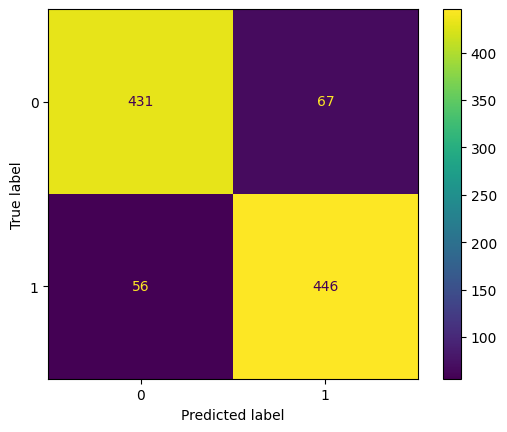

In [11]:
# ¿Lo hizo bien? Evaluar
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Comparo los datos reales de test con los predichos
cm = confusion_matrix(y_test, y_pred_log_reg)
ConfusionMatrixDisplay(cm).plot()

In [12]:
(56+67)*100/(1000)

12.3

In [13]:
# ¿Cuáles son las variables más importantes?
importance = log_reg.coef_[0]
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})
importance_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
4,last_login_days,2.106871
5,region,0.071294
0,age,0.013351
11,favorite_genre,0.002642
8,payment_method,-0.028161
6,device,-0.030263
1,gender,-0.068106
2,subscription_type,-0.478728
7,monthly_fee,-0.570628
9,number_of_profiles,-0.972962


2.2. Modelo de Random Forest: Árboles aleatorios - ¿Cuántos votos aporta cada grupo?

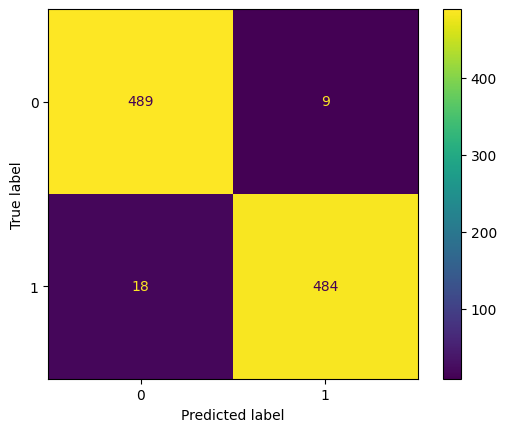

In [14]:
# Modelo de Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()
random_forest.fit(X_train_scaled, y_train) # Ajusto con datos de entrenamiento
y_pred_random_forest = random_forest.predict(X_test_scaled) # Predicción
y_pred_random_forest[:10]

# ¿Lo hizo bien? Evaluar
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_random_forest)
ConfusionMatrixDisplay(cm).plot()

In [15]:
# ¿Cuáles son las variables más importantes?
importance_rf = random_forest.feature_importances_
features = X_train.columns
importance_df_rf = pd.DataFrame({
    'Feature': features, 
    'Importance': importance_rf
})
importance_df_rf.sort_values(by='Importance', ascending=False)

,Feature,Importance
10,avg_watch_time_per_day,0.392827
3,watch_hours,0.208346
4,last_login_days,0.185109
9,number_of_profiles,0.062895
8,payment_method,0.037170
7,monthly_fee,0.024041
0,age,0.023657
2,subscription_type,0.022559
11,favorite_genre,0.012656
5,region,0.011972


2.2 XGBoost: Árboles aleatorios secuenciales -> Los árboles de decisión se van corrigiendo así mismos

In [16]:
from xgboost import XGBClassifier

xgboost = XGBClassifier()
xgboost.fit(X_train_scaled, y_train)
y_pred_xgboost = xgboost.predict(X_test_scaled)
y_pred_xgboost[:10]

array([0, 1, 0, 1, 1, 1, 0, 1, 0, 0])

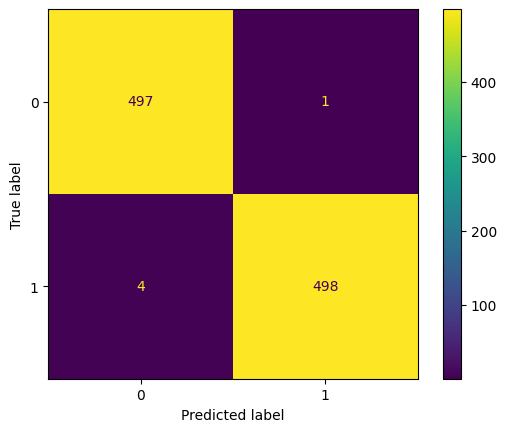

In [17]:
cm = confusion_matrix(y_test, y_pred_xgboost)
ConfusionMatrixDisplay(cm).plot()

In [18]:
# ¿Cuáles son las variables más importantes?
importance_xgb = xgboost.feature_importances_
features = X_train.columns
importance_df_xgb = pd.DataFrame({
    'Feature': features, 
    'Importance': importance_xgb
})
importance_df_xgb.sort_values(by='Importance', ascending=False)

,Feature,Importance
10,avg_watch_time_per_day,0.575732
2,subscription_type,0.097379
9,number_of_profiles,0.082558
8,payment_method,0.074302
4,last_login_days,0.064766
3,watch_hours,0.062951
11,favorite_genre,0.010622
5,region,0.009402
6,device,0.008858
0,age,0.005959


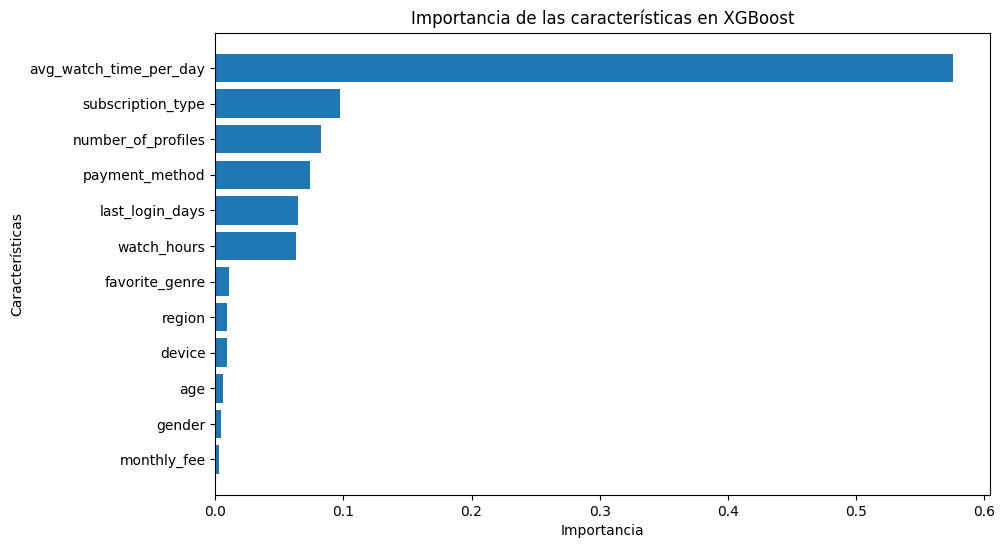

In [19]:
# Solo vamos a graficar las variables más influyentes
from matplotlib import pyplot as plt
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(importance_df_xgb['Feature'], importance_df_xgb['Importance'])
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de las características en XGBoost')
plt.show()

##### Analizando la variable más importante

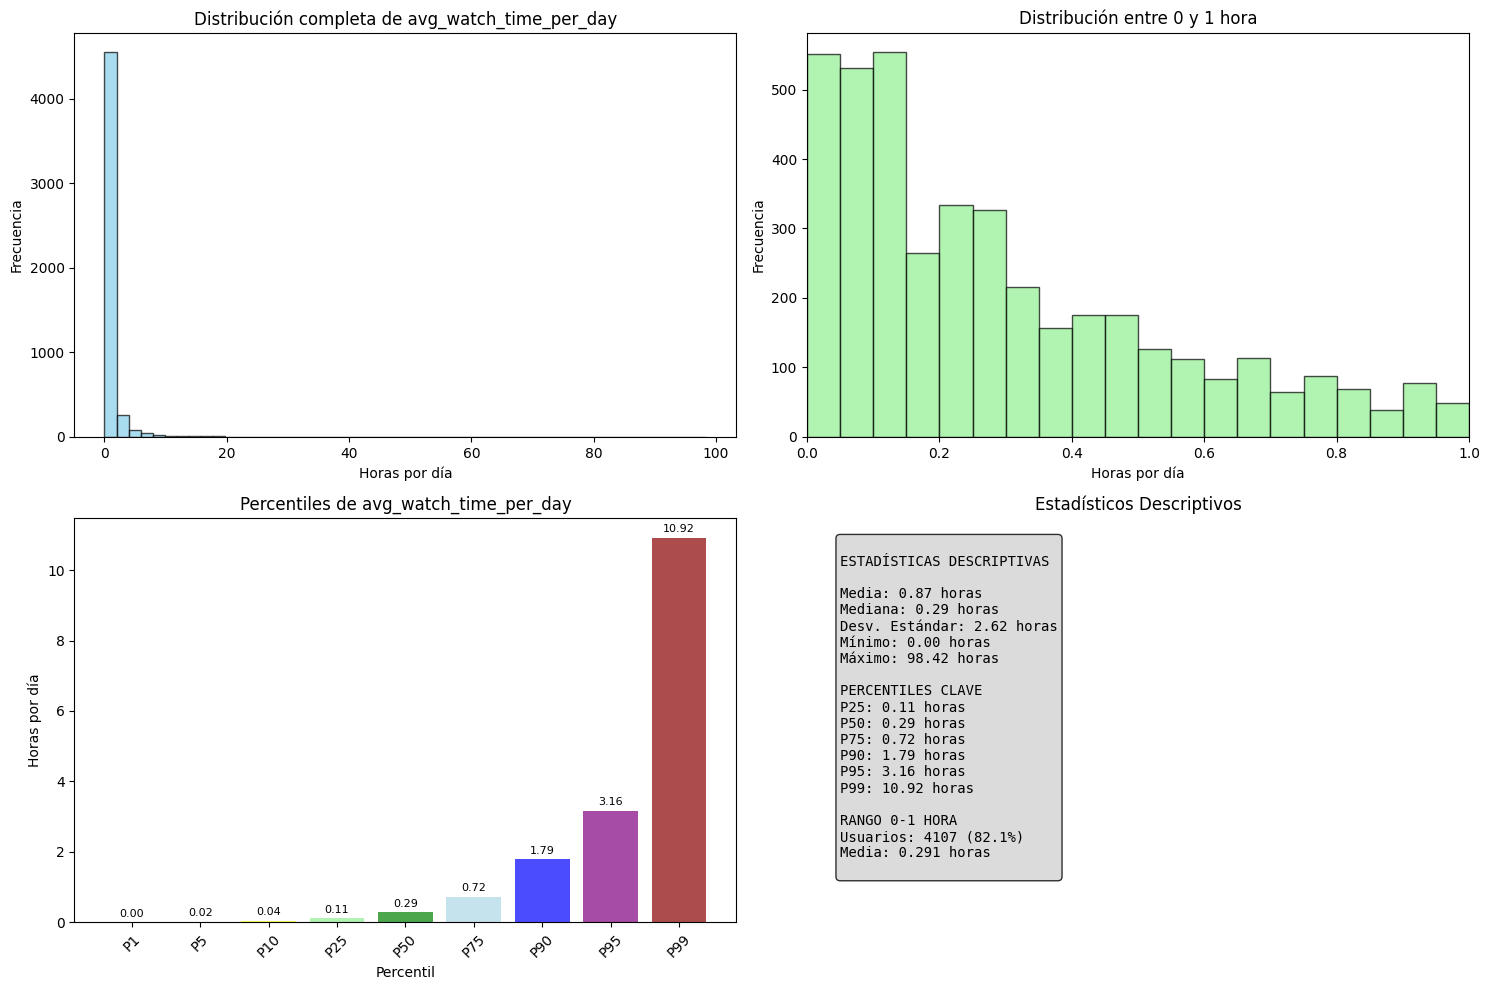

=== PERCENTILES DETALLADOS ===
P1.0: 0.00 horas
P5.0: 0.02 horas
P10.0: 0.04 horas
P25.0: 0.11 horas
P50.0: 0.29 horas
P75.0: 0.72 horas
P90.0: 1.79 horas
P95.0: 3.16 horas
P99.0: 10.92 horas


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Configurar el estilo
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histograma completo
axes[0, 0].hist(X['avg_watch_time_per_day'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribución completa de avg_watch_time_per_day')
axes[0, 0].set_xlabel('Horas por día')
axes[0, 0].set_ylabel('Frecuencia')

# 2. Histograma entre 0 y 1 hora
data_0_1 = X[X['avg_watch_time_per_day'] <= 1]['avg_watch_time_per_day']
axes[0, 1].hist(data_0_1, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribución entre 0 y 1 hora')
axes[0, 1].set_xlabel('Horas por día')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_xlim(0, 1)

# 3. Gráfico de percentiles más claro
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
percentile_values = X['avg_watch_time_per_day'].quantile([p/100 for p in percentiles])

# Crear barras para percentiles
colors = ['red', 'orange', 'yellow', 'lightgreen', 'green', 'lightblue', 'blue', 'purple', 'darkred']
bars = axes[1, 0].bar(range(len(percentiles)), percentile_values, color=colors, alpha=0.7)
axes[1, 0].set_title('Percentiles de avg_watch_time_per_day')
axes[1, 0].set_xlabel('Percentil')
axes[1, 0].set_ylabel('Horas por día')
axes[1, 0].set_xticks(range(len(percentiles)))
axes[1, 0].set_xticklabels([f'P{p}' for p in percentiles], rotation=45)

# Agregar valores en las barras
for i, (bar, value) in enumerate(zip(bars, percentile_values)):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                     f'{value:.2f}', ha='center', va='bottom', fontsize=8)

# 4. Estadísticos descriptivos
stats_text = f"""
ESTADÍSTICAS DESCRIPTIVAS

Media: {X['avg_watch_time_per_day'].mean():.2f} horas
Mediana: {X['avg_watch_time_per_day'].median():.2f} horas
Desv. Estándar: {X['avg_watch_time_per_day'].std():.2f} horas
Mínimo: {X['avg_watch_time_per_day'].min():.2f} horas
Máximo: {X['avg_watch_time_per_day'].max():.2f} horas

PERCENTILES CLAVE
P25: {X['avg_watch_time_per_day'].quantile(0.25):.2f} horas
P50: {X['avg_watch_time_per_day'].quantile(0.50):.2f} horas
P75: {X['avg_watch_time_per_day'].quantile(0.75):.2f} horas
P90: {X['avg_watch_time_per_day'].quantile(0.90):.2f} horas
P95: {X['avg_watch_time_per_day'].quantile(0.95):.2f} horas
P99: {X['avg_watch_time_per_day'].quantile(0.99):.2f} horas

RANGO 0-1 HORA
Usuarios: {len(data_0_1)} ({len(data_0_1)/len(X)*100:.1f}%)
Media: {data_0_1.mean():.3f} horas
"""

axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
axes[1, 1].set_title('Estadísticos Descriptivos')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Imprimir percentiles detallados
print("=== PERCENTILES DETALLADOS ===")
for p, value in zip(percentiles, percentile_values):
    print(f"P{p:2.1f}: {value:.2f} horas")

##### Relación entre las horas promedio por día y el churn

C:\Users\DELL\AppData\Local\Temp\ipykernel_31948\2919587613.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_range = df_netflix.groupby('watch_time_range')['churned'].agg(['count', 'sum', 'mean'])


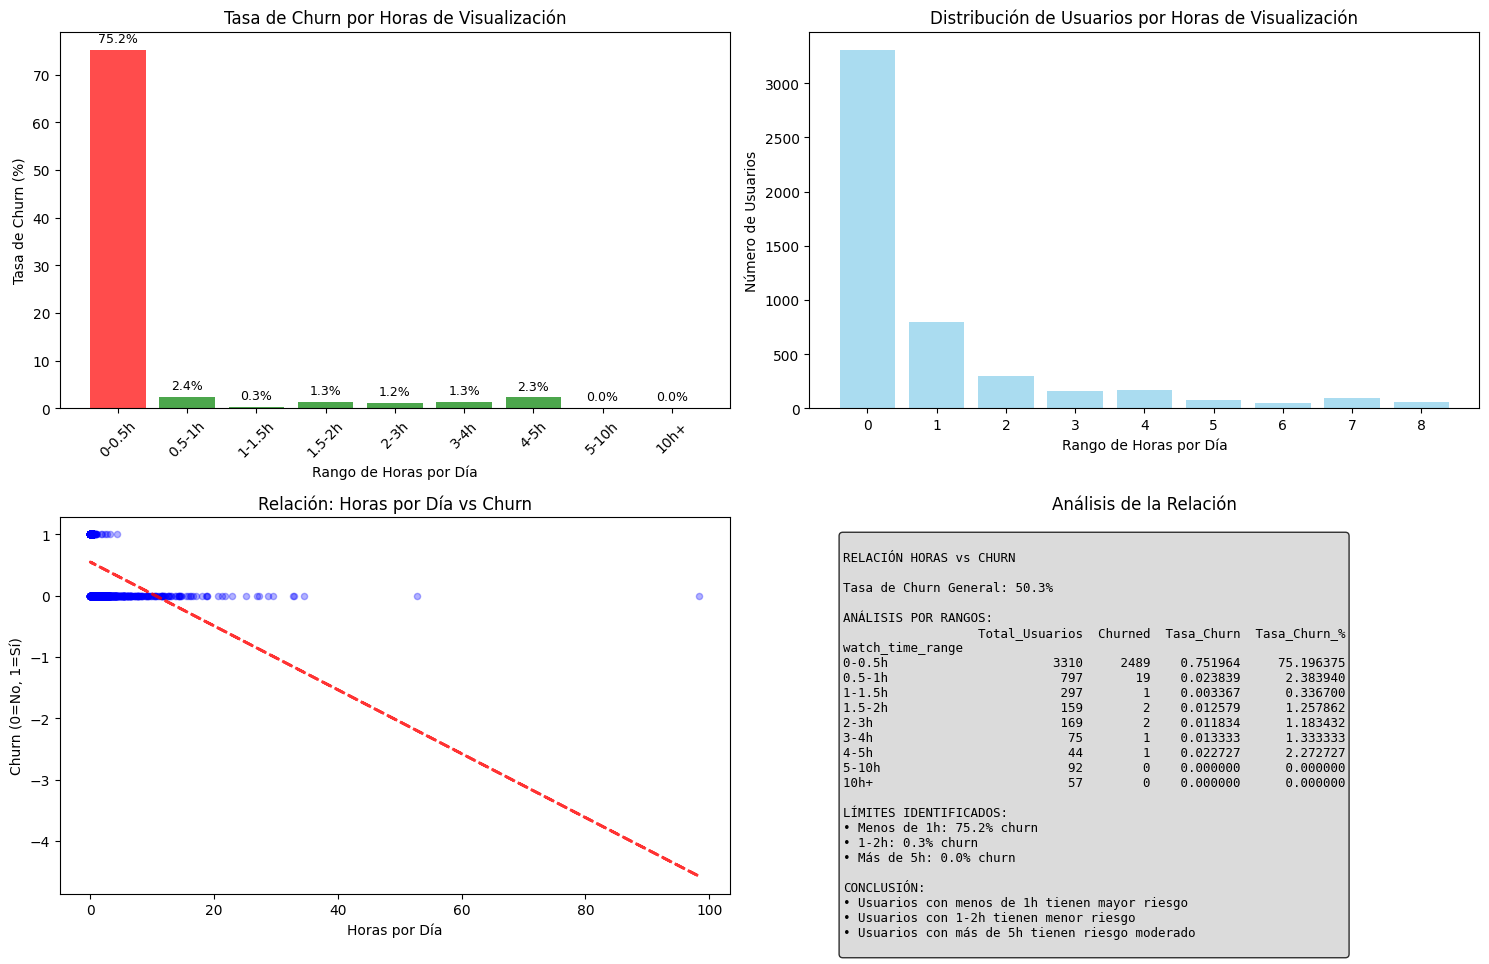


=== RESUMEN DE LA RELACIÓN HORAS vs CHURN ===
                  Total_Usuarios  Churned  Tasa_Churn  Tasa_Churn_%
watch_time_range                                                   
0-0.5h                      3310     2489        0.75         75.20
0.5-1h                       797       19        0.02          2.38
1-1.5h                       297        1        0.00          0.34
1.5-2h                       159        2        0.01          1.26
2-3h                         169        2        0.01          1.18
3-4h                          75        1        0.01          1.33
4-5h                          44        1        0.02          2.27
5-10h                         92        0        0.00          0.00
10h+                          57        0        0.00          0.00


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Crear rangos de horas para análisis
bins = [0, 0.5, 1, 1.5, 2, 3, 4, 5, 10, float('inf')]
labels = ['0-0.5h', '0.5-1h', '1-1.5h', '1.5-2h', '2-3h', '3-4h', '4-5h', '5-10h', '10h+']

# Agregar columna de rangos al dataframe
df_netflix['watch_time_range'] = pd.cut(df_netflix['avg_watch_time_per_day'], 
                                       bins=bins, labels=labels, include_lowest=True)

# Calcular tasa de churn por rango
churn_by_range = df_netflix.groupby('watch_time_range')['churned'].agg(['count', 'sum', 'mean'])
churn_by_range.columns = ['Total_Usuarios', 'Churned', 'Tasa_Churn']
churn_by_range['Tasa_Churn_%'] = churn_by_range['Tasa_Churn'] * 100

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Tasa de churn por rango de horas
bars = axes[0, 0].bar(range(len(churn_by_range)), churn_by_range['Tasa_Churn_%'], 
                      color=['red' if x > 50 else 'green' for x in churn_by_range['Tasa_Churn_%']], alpha=0.7)
axes[0, 0].set_title('Tasa de Churn por Horas de Visualización')
axes[0, 0].set_xlabel('Rango de Horas por Día')
axes[0, 0].set_ylabel('Tasa de Churn (%)')
axes[0, 0].set_xticks(range(len(churn_by_range)))
axes[0, 0].set_xticklabels(churn_by_range.index, rotation=45)

# Agregar valores en las barras
for i, (bar, value) in enumerate(zip(bars, churn_by_range['Tasa_Churn_%'])):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                     f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. Número de usuarios por rango
axes[0, 1].bar(range(len(churn_by_range)), churn_by_range['Total_Usuarios'], 
               color='skyblue', alpha=0.7)
axes[0, 1].set_title('Distribución de Usuarios por Horas de Visualización')
axes[0, 1].set_xlabel('Rango de Horas por Día')
axes[0, 1].set_ylabel('Número de Usuarios')
axes[0, 1].set_xticks(range(len(churn_by_range)))
axes[0, 0].set_xticklabels(churn_by_range.index, rotation=45)

# 3. Scatter plot: Horas vs Churn
axes[1, 0].scatter(df_netflix['avg_watch_time_per_day'], df_netflix['churned'], 
                   alpha=0.3, s=20, color='blue')
axes[1, 0].set_title('Relación: Horas por Día vs Churn')
axes[1, 0].set_xlabel('Horas por Día')
axes[1, 0].set_ylabel('Churn (0=No, 1=Sí)')

# Agregar línea de tendencia
z = np.polyfit(df_netflix['avg_watch_time_per_day'], df_netflix['churned'], 1)
p = np.poly1d(z)
axes[1, 0].plot(df_netflix['avg_watch_time_per_day'], p(df_netflix['avg_watch_time_per_day']), 
                "r--", alpha=0.8, linewidth=2)

# 4. Estadísticos de la relación
stats_text = f"""
RELACIÓN HORAS vs CHURN

Tasa de Churn General: {df_netflix['churned'].mean()*100:.1f}%

ANÁLISIS POR RANGOS:
{churn_by_range.to_string()}

LÍMITES IDENTIFICADOS:
• Menos de 1h: {churn_by_range.loc['0-0.5h', 'Tasa_Churn_%']:.1f}% churn
• 1-2h: {churn_by_range.loc['1-1.5h', 'Tasa_Churn_%']:.1f}% churn
• Más de 5h: {churn_by_range.loc['5-10h', 'Tasa_Churn_%']:.1f}% churn

CONCLUSIÓN:
{chr(8226)} Usuarios con menos de 1h tienen mayor riesgo
{chr(8226)} Usuarios con 1-2h tienen menor riesgo
{chr(8226)} Usuarios con más de 5h tienen riesgo moderado
"""

axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes, 
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
axes[1, 1].set_title('Análisis de la Relación')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Imprimir tabla resumen
print("\n=== RESUMEN DE LA RELACIÓN HORAS vs CHURN ===")
print(churn_by_range.round(2))

#### 3. Métricas más importantes

* Accuracy score: Predicciones correctas / total predicciones - Fórmula: (TP + TN) / (TP + TN + FP + FN)
* Precision score: Predicciones correctas / total predicciones - Fórmula: TP / (TP + FP)
* Recall score: Predicciones correctas / total predicciones - Fórmula: TP / (TP + FN)
* F1 score: Media armónica de la precision y el recall - Fórmula: 2 * (precision * recall) / (precision + recall)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


y_pred_list = [("Logistic Regression", y_pred_log_reg, log_reg), ("Random Forest", y_pred_random_forest, random_forest), ("XGBoost", y_pred_xgboost, xgboost)    ]

for model_name, y_pred, model in y_pred_list:
    print(f"Modelo: {model_name}")
    print(f"Accuracy score: {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision score: {precision_score(y_test, y_pred, average='weighted'):.2f}")
    print(f"Recall score: {recall_score(y_test, y_pred, average='weighted'):.2f}")
    print(f"F1 score: {f1_score(y_test, y_pred, average='weighted'):.2f}")
    print("--------------------------------")



Modelo: Logistic Regression
Accuracy score: 0.88
Precision score: 0.88
Recall score: 0.88
F1 score: 0.88
--------------------------------
Modelo: Random Forest
Accuracy score: 0.97
Precision score: 0.97
Recall score: 0.97
F1 score: 0.97
--------------------------------
Modelo: XGBoost
Accuracy score: 0.99
Precision score: 1.00
Recall score: 0.99
F1 score: 1.00
--------------------------------


Bonus: ¿Cómo validar que no hayamos tenido sobreajuste?

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

for col in categorical_features:
    X[col] = label_encoder.fit_transform(X[col])
X_scaled = standard_scaler.fit_transform(X)

# Usar todo el dataset para CV
models = {
    'Logistic Regression': log_reg,
    'Random Forest': random_forest,
    'XGBoost': xgboost
}

# Métricas para evaluar
metrics = ['accuracy', 'precision', 'recall', 'f1']

for model_name, model in models.items():
    print(f"Model: {model_name}")
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calcular todas las métricas
    metric_scores = {}
    for metric in metrics:
        scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring=metric)
        metric_scores[metric] = (scores.mean(), scores.std())
    
    # Mostrar resultados
    for metric, (mean_score, std_score) in metric_scores.items():
        print(f"{metric.capitalize()}: {mean_score:.3f} (+/- {std_score * 2:.3f})")
    
    print("--------------------------------")

Model: Logistic Regression
Accuracy: 0.884 (+/- 0.018)
Precision: 0.880 (+/- 0.017)
Recall: 0.890 (+/- 0.020)
F1: 0.885 (+/- 0.016)
--------------------------------
Model: Random Forest
Accuracy: 0.972 (+/- 0.014)
Precision: 0.980 (+/- 0.006)
Recall: 0.964 (+/- 0.013)
F1: 0.971 (+/- 0.012)
--------------------------------
Model: XGBoost
Accuracy: 0.994 (+/- 0.007)
Precision: 0.997 (+/- 0.003)
Recall: 0.990 (+/- 0.010)
F1: 0.994 (+/- 0.006)
--------------------------------
